CLUSTER_VARS: ['racel_dv', 'doby_dv', 'fimngrs_dv', 'nchild_dv', 'hhsize']
Synthetic population: ../data/6_synthetic_population/synthetic_population.parquet
Reference dir: /Users/jimmy/Projects/archetypes/data_pipeline/reference
RACEL raw: /Users/jimmy/Projects/archetypes/data_pipeline/reference/ukhls_categorical/racel_raw_ukhl.csv
  UKHLS collapsed (config recode → group_labels): 10 groups; e.g. White 1.0 = 63.72% Mixed 2.0 = 1.57%
Rows scanned: 525,150
Continuous (sample): {'o_doby_dv': {'mean': 49.24635247072265, 'std': np.float64(16.232181693565106), 'n': 525150}, 'o_fimngrs_dv': {'mean': 2289.981318918277, 'std': np.float64(1856.270983966414), 'n': 525150}, 'o_nchild_dv': {'mean': 0.5277558792725888, 'std': np.float64(0.9200910360513034), 'n': 525150}, 'o_hhsize': {'mean': 3.22357992954394, 'std': np.float64(1.7442626723834673), 'n': 525150}}
Saved ../data/6b_synthetic_vs_ukhls/categorical_racel_dv_compare.csv


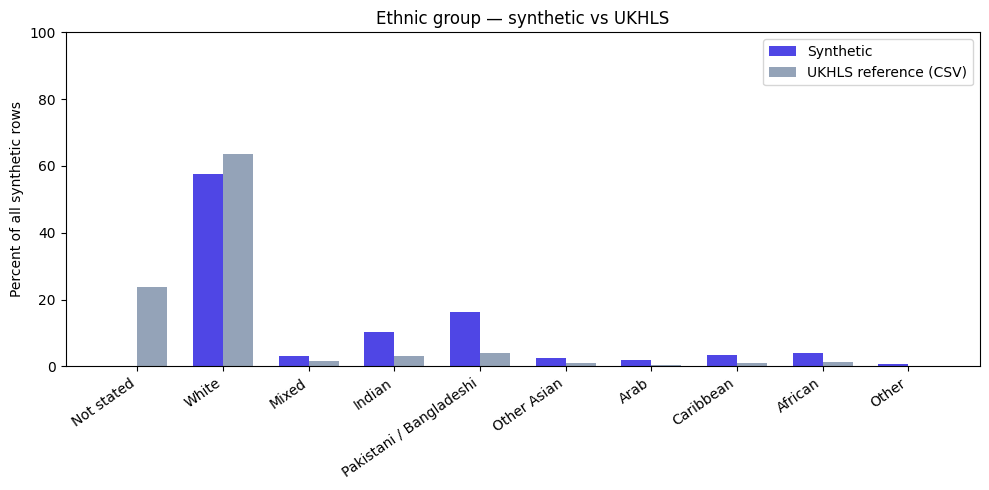

Saved ../data/6b_synthetic_vs_ukhls/categorical_sex_dv_compare.csv


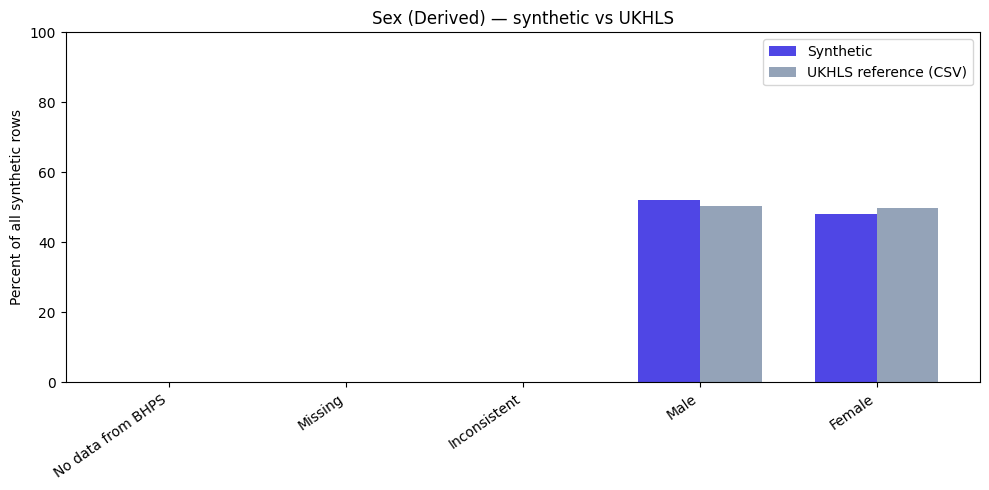

Saved ../data/6b_synthetic_vs_ukhls/categorical_hiqual_dv_compare.csv


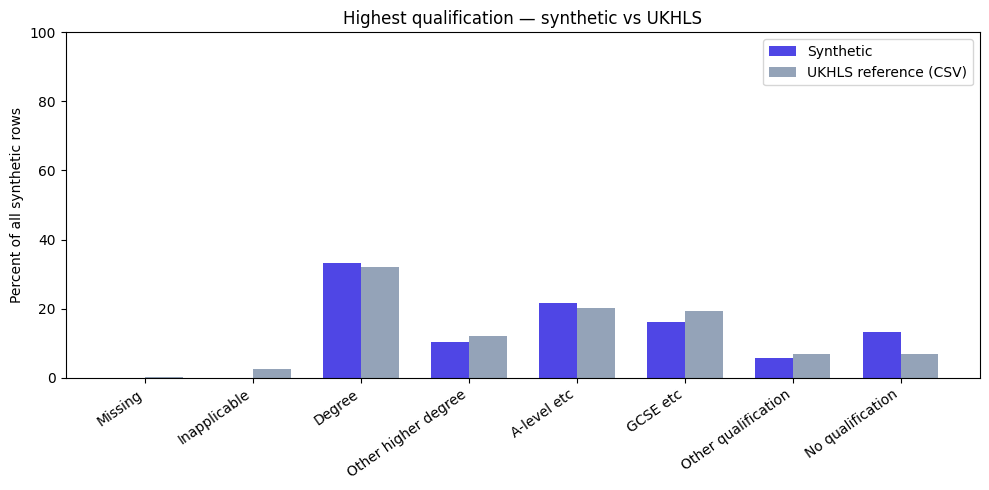

,variable,label,syn_mean,syn_std,syn_n,ukhls_mean,ukhls_std,ukhls_n
0,doby_dv,Age / Year of birth (Derived),49.246352,16.232182,525150,38.35,23.00,20177.0
1,fimngrs_dv,Total monthly personal income (Gross),2289.981319,1856.270984,525150,2399.46,3679.13,32849.0
2,nchild_dv,Number of own children in household,0.527756,0.920091,525150,0.29,0.70,48896.0
3,hhsize,Household size,3.223580,1.744263,525150,NaN,NaN,NaN


Saved ../data/6b_synthetic_vs_ukhls/continuous_compare.csv
Saved ../data/6b_synthetic_vs_ukhls/report.html


In [2]:
"""6b — Synthetic population vs UKHLS reference (report). Run after 6a_synthetic_population.

Reads data_pipeline/reference/ukhls_continuous_reference.csv and reference/ukhls_categorical/*.csv,
scans synthetic_population.parquet in chunks, writes CSVs + PNGs + report.html under
{DATA_FOLDER}/6b_synthetic_vs_ukhls/.

Optional UKHLS_REFERENCE dict: categorical label -> % override; continuous {"mean","std"} override.
"""

# ── Optional overrides (figures default from reference CSVs) ──────────────
UKHLS_REFERENCE = {
    "racel_dv": {},
    "sex_dv": {},
    "hiqual_dv": {},
    "nchild_dv": {"mean": None, "std": None},
    "has_child": {"mean": None, "std": None},
    "hhsize": {"mean": None, "std": None},
    "doby_dv": {"mean": None, "std": None},
    "fimngrs_dv": {"mean": None, "std": None},
}

SHOW_UKHLS_IN_PLOTS = True
REPORT_CATEGORICAL = ["racel_dv", "sex_dv", "hiqual_dv"]

# ── Imports & paths ───────────────────────────────────────────────────────
import os
import sys
from pathlib import Path
from html import escape
from datetime import datetime, timezone

sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

import importlib
import data_pipeline.config_variables as _cv
import data_pipeline.config_cluster as _cc
_cv.reload_config_variables()
importlib.reload(_cc)

from data_pipeline.config_paths import DATA_FOLDER
from data_pipeline.config_variables import CLUSTER_VARS, VARIABLES, CATEGORY_MAPS, RECODE_MAPS
from data_pipeline.config_cluster import WAVE
from data_pipeline.helpers.ukhls_categorical_aggregate import (
    pipeline_reference_dir,
    racel_collapsed_percent_from_raw,
)

SYNPOP = Path(f"../{DATA_FOLDER}/6_synthetic_population/synthetic_population.parquet")
OUT_DIR = Path(f"../{DATA_FOLDER}/6b_synthetic_vs_ukhls")
OUT_DIR.mkdir(parents=True, exist_ok=True)
BATCH_ROWS = 500_000

REFERENCE_DIR = pipeline_reference_dir()
CONTINUOUS_REF_CSV = REFERENCE_DIR / "ukhls_continuous_reference.csv"
CATEGORICAL_REF_DIR = REFERENCE_DIR / "ukhls_categorical"

# UKHLS ethnicity (collapsed): same remapping as 4a — RECODE_MAPS["racel_dv"] from
# config_variables_demographics.racel_dv["recode"] (via config_variables.RECODE_MAPS).
# We sum percentages in racel_raw_ukhl.csv (detailed UKHLS codes) into group_labels 0–9.
RACEL_RAW_CSV = CATEGORICAL_REF_DIR / "racel_raw_ukhl.csv"
RACEL_RECODE = RECODE_MAPS["racel_dv"]
RACEL_UKHL_COLLAPSED_PCT = racel_collapsed_percent_from_raw(RACEL_RAW_CSV, RACEL_RECODE)
if RACEL_RAW_CSV.exists() and not RACEL_UKHL_COLLAPSED_PCT:
    raise RuntimeError(
        f"racel_raw_ukhl aggregation empty but file exists: {RACEL_RAW_CSV}. "
        "Check RECODE_MAPS['racel_dv'] covers every category_code in that CSV."
    )

if not SYNPOP.exists():
    raise FileNotFoundError(f"Run step 5 first: {SYNPOP}")

print("CLUSTER_VARS:", CLUSTER_VARS)
print("Synthetic population:", SYNPOP)
print("Reference dir:", REFERENCE_DIR.resolve())
print("RACEL raw:", RACEL_RAW_CSV.resolve())
print(
    "  UKHLS collapsed (config recode → group_labels):",
    len(RACEL_UKHL_COLLAPSED_PCT),
    "groups; e.g. White 1.0 =",
    f"{RACEL_UKHL_COLLAPSED_PCT.get(1.0, float('nan')):.2f}%",
    "Mixed 2.0 =",
    f"{RACEL_UKHL_COLLAPSED_PCT.get(2.0, float('nan')):.2f}%",
)


def load_continuous_reference(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


def load_categorical_reference(var_code: str) -> pd.DataFrame:
    p = CATEGORICAL_REF_DIR / f"{var_code}.csv"
    if not p.exists():
        return pd.DataFrame()
    return pd.read_csv(p)


def collect_synthetic_stats(parquet_path: Path, batch_rows: int, ref_continuous: pd.DataFrame) -> dict:
    """Single chunked pass: racel OHE, extra categoricals (sex, hiqual), continuous cluster + reference rows."""
    pf = pq.ParquetFile(parquet_path)
    schema_names = set(pf.schema_arrow.names)
    wave = WAVE

    ohe_racel = [f"{wave}_racel_dv_{int(k)}" for k in sorted(CATEGORY_MAPS["racel_dv"].keys())]
    ohe_racel = [c for c in ohe_racel if c in schema_names]

    cont_cluster = [f"{wave}_{b}" for b in CLUSTER_VARS if not VARIABLES[b]["categorical"]]
    cont_cluster = [c for c in cont_cluster if c in schema_names]

    cont_ref_extra = []
    if not ref_continuous.empty:
        for _, row in ref_continuous.iterrows():
            base = str(row["variable_code"]).strip()
            col = f"{wave}_{base}"
            if col in schema_names and col not in cont_cluster:
                cont_ref_extra.append(col)

    cont_cols = list(dict.fromkeys(cont_cluster + cont_ref_extra))

    sex_c = f"{wave}_sex_dv"
    hq_c = f"{wave}_hiqual_dv"
    extra_cat = [c for c in (sex_c, hq_c) if c in schema_names]

    need = list(dict.fromkeys(ohe_racel + cont_cols + extra_cat))

    sums_ohe = {c: 0.0 for c in ohe_racel}
    n_total = 0

    sum_x = {c: 0.0 for c in cont_cols}
    sum_x2 = {c: 0.0 for c in cont_cols}
    n_cont = {c: 0 for c in cont_cols}

    sex_counts = {}
    hiqual_counts = {}

    for batch in pf.iter_batches(batch_size=batch_rows, columns=need):
        df = batch.to_pandas()
        n_batch = len(df)
        n_total += n_batch

        for c in ohe_racel:
            sums_ohe[c] += pd.to_numeric(df[c], errors="coerce").fillna(0.0).sum()

        for c in cont_cols:
            x = pd.to_numeric(df[c], errors="coerce").to_numpy(dtype=float)
            m = np.isfinite(x)
            if not m.any():
                continue
            xv = x[m]
            n_cont[c] += int(m.sum())
            sum_x[c] += float(xv.sum())
            sum_x2[c] += float(np.dot(xv, xv))

        if sex_c in df.columns:
            s = pd.to_numeric(df[sex_c], errors="coerce")
            for k, v in s.value_counts(dropna=False).items():
                kk = float(k) if pd.notna(k) else np.nan
                sex_counts[kk] = sex_counts.get(kk, 0) + int(v)

        if hq_c in df.columns:
            h = pd.to_numeric(df[hq_c], errors="coerce")
            h = h.replace({9.0: 6.0})
            for k, v in h.value_counts(dropna=False).items():
                kk = float(k) if pd.notna(k) else np.nan
                hiqual_counts[kk] = hiqual_counts.get(kk, 0) + int(v)

    pct_racel = {c: (sums_ohe[c] / n_total * 100.0) if n_total else 0.0 for c in ohe_racel}

    mean = {}
    std_cont = {}
    for c in cont_cols:
        n = n_cont[c]
        if n == 0:
            mean[c] = np.nan
            std_cont[c] = np.nan
            continue
        mean[c] = sum_x[c] / n
        if n < 2:
            std_cont[c] = np.nan
        else:
            var = sum_x2[c] / n - mean[c] ** 2
            std_cont[c] = np.sqrt(max(0.0, var))

    def counts_to_pct(counts: dict, denom: int) -> dict:
        if denom <= 0:
            return {}
        return {k: (v / denom * 100.0) for k, v in counts.items()}

    return {
        "n_total": n_total,
        "ohe_racel_pct": pct_racel,
        "racel_labels": CATEGORY_MAPS["racel_dv"],
        "continuous": {c: {"mean": mean[c], "std": std_cont[c], "n": n_cont[c]} for c in cont_cols},
        "sex_counts": sex_counts,
        "sex_pct": counts_to_pct(sex_counts, n_total),
        "hiqual_counts": hiqual_counts,
        "hiqual_pct": counts_to_pct(hiqual_counts, n_total),
    }


ref_continuous_df = load_continuous_reference(CONTINUOUS_REF_CSV)
stats = collect_synthetic_stats(SYNPOP, BATCH_ROWS, ref_continuous_df)
print(f"Rows scanned: {stats['n_total']:,}")
print("Continuous (sample):", {k: stats["continuous"][k] for k in list(stats["continuous"])[:5]})


def _code_key(x):
    if pd.isna(x):
        return np.nan
    return float(x)


def ukhls_pct_from_row(var: str, row: pd.Series) -> float | None:
    lab = str(row["label"]).strip()
    ovr = (UKHLS_REFERENCE.get(var) or {}).get(lab)
    if ovr is not None and not (isinstance(ovr, float) and np.isnan(ovr)):
        return float(ovr)
    p = row.get("percent")
    if pd.notna(p) and str(p).strip() != "":
        return float(p)
    # racel: collapsed CSV often omits White/Mixed; fill from raw table + RACEL_RECODE (config)
    if var == "racel_dv" and RACEL_UKHL_COLLAPSED_PCT:
        code = _code_key(row["category_code"])
        if pd.isna(code):
            return None
        code = float(code)
        if code in RACEL_UKHL_COLLAPSED_PCT:
            return float(RACEL_UKHL_COLLAPSED_PCT[code])
        for k, v in RACEL_UKHL_COLLAPSED_PCT.items():
            if abs(float(k) - code) < 1e-9:
                return float(v)
    return None


def synthetic_pct_for_category(var: str, code: float, stats: dict) -> float:
    wv = WAVE
    if var == "racel_dv":
        k = int(code) if not np.isnan(code) else 0
        return float(stats["ohe_racel_pct"].get(f"{wv}_racel_dv_{k}", 0.0))
    if var == "sex_dv":
        return float(stats["sex_pct"].get(code, 0.0))
    if var == "hiqual_dv":
        return float(stats["hiqual_pct"].get(code, 0.0))
    return 0.0


categorical_tables = {}

for var in REPORT_CATEGORICAL:
    ref_df = load_categorical_reference(var)
    if ref_df.empty:
        print(f"Skip {var}: no {CATEGORICAL_REF_DIR / (var + '.csv')}")
        continue

    rows_out = []
    syn_list, uk_list, labels = [], [], []
    for _, row in ref_df.iterrows():
        code = _code_key(row["category_code"])
        lab = str(row["label"])
        syn = synthetic_pct_for_category(var, code, stats)
        uk = ukhls_pct_from_row(var, row)
        syn_list.append(syn)
        labels.append(lab)
        uk_list.append(uk if uk is not None else np.nan)
        rows_out.append(
            {
                "category_code": code,
                "label": lab,
                "syn_percent": syn,
                "ukhls_percent": uk,
                "delta": (syn - uk) if uk is not None and not pd.isna(uk) else np.nan,
            }
        )

    # Synthetic parquet can have NaN or codes not listed in reference/*.csv; those still count in n_total.
    syn_sum = sum(syn_list)
    remainder_syn = max(0.0, 100.0 - syn_sum)
    if remainder_syn > 1e-4:
        syn_list.append(remainder_syn)
        labels.append("Not in reference CSV (incl. NaN)")
        uk_list.append(np.nan)
        rows_out.append(
            {
                "category_code": np.nan,
                "label": "Not in reference CSV (incl. NaN)",
                "syn_percent": remainder_syn,
                "ukhls_percent": np.nan,
                "delta": np.nan,
            }
        )

    categorical_tables[var] = pd.DataFrame(rows_out)
    out_t = OUT_DIR / f"categorical_{var}_compare.csv"
    categorical_tables[var].to_csv(out_t, index=False)
    print(f"Saved {out_t}")

    x = np.arange(len(labels))
    bar_w = 0.35
    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 0.9), 5))
    ax.bar(x - bar_w / 2, syn_list, width=bar_w, label="Synthetic", color="#4f46e5")
    if SHOW_UKHLS_IN_PLOTS and np.any(np.isfinite(np.array(uk_list, dtype=float))):
        ax.bar(x + bar_w / 2, uk_list, width=bar_w, label="UKHLS reference (CSV)", color="#94a3b8")
    ax.set_xticks(x)
    rot = 35 if len(labels) > 4 else 0
    ax.set_xticklabels(labels, rotation=rot, ha="right" if rot else "center")
    ax.set_ylabel("Percent of all synthetic rows")
    title = VARIABLES.get(var, {}).get("label", var)
    ax.set_title(f"{title} — synthetic vs UKHLS")
    ax.legend()
    ymax = max([*syn_list, *[u for u in uk_list if np.isfinite(u)]], default=0) * 1.15
    ax.set_ylim(0, max(100, ymax))
    fig.tight_layout()
    fname = OUT_DIR / f"{var}_synthetic_vs_ukhls.png"
    fig.savefig(fname, dpi=150)
    plt.show()


rows = []


def ref_row_for_base(base: str):
    if ref_continuous_df.empty:
        return None
    m = ref_continuous_df["variable_code"].astype(str).str.strip() == base
    if not m.any():
        return None
    return ref_continuous_df.loc[m].iloc[0]


def ukhls_mean_std(base: str, ref_row: pd.Series | None):
    ovr = UKHLS_REFERENCE.get(base) or {}
    om, os_ = ovr.get("mean"), ovr.get("std")
    if om is not None and not (isinstance(om, float) and np.isnan(om)):
        mean = om
    elif ref_row is not None and pd.notna(ref_row.get("mean")):
        mean = float(ref_row["mean"])
    else:
        mean = np.nan
    if os_ is not None and not (isinstance(os_, float) and np.isnan(os_)):
        std = os_
    elif ref_row is not None and pd.notna(ref_row.get("std_dev")):
        std = float(ref_row["std_dev"])
    else:
        std = np.nan
    return mean, std


def ukhls_n_ref(base: str, ref_row: pd.Series | None):
    if ref_row is not None and pd.notna(ref_row.get("n")):
        try:
            return int(float(ref_row["n"]))
        except (TypeError, ValueError):
            return np.nan
    return np.nan


bases_order = []
if not ref_continuous_df.empty:
    for b in ref_continuous_df["variable_code"].astype(str).str.strip():
        if b not in bases_order:
            bases_order.append(b)
for b in CLUSTER_VARS:
    if VARIABLES[b]["categorical"]:
        continue
    if b not in bases_order:
        bases_order.append(b)

for base in bases_order:
    col = f"{WAVE}_{base}"
    s = stats["continuous"].get(col)
    if not s:
        continue
    ref_row = ref_row_for_base(base)
    um, us = ukhls_mean_std(base, ref_row)
    rows.append(
        {
            "variable": base,
            "label": VARIABLES.get(base, {}).get("label", base),
            "syn_mean": s["mean"],
            "syn_std": s["std"],
            "syn_n": s["n"],
            "ukhls_mean": um,
            "ukhls_std": us,
            "ukhls_n": ukhls_n_ref(base, ref_row),
        }
    )

df_cmp = pd.DataFrame(rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
display(df_cmp)
out_csv = OUT_DIR / "continuous_compare.csv"
df_cmp.to_csv(out_csv, index=False)
print(f"Saved {out_csv}")

parts = [
    "<!DOCTYPE html>",
    "<html><head><meta charset='utf-8'><title>6b Synthetic vs UKHLS</title>",
    "<style>body{font-family:system-ui,sans-serif;max-width:960px;margin:2rem auto;line-height:1.5;}",
    "table{border-collapse:collapse;width:100%;margin:1rem 0;}",
    "th,td{border:1px solid #ccc;padding:0.4rem 0.6rem;text-align:right;}",
    "th:first-child,td:first-child{text-align:left;}",
    "h2{margin-top:2rem;} img{max-width:100%;height:auto;}</style></head><body>",
    f"<h1>Synthetic population vs UKHLS reference</h1>",
    f"<p>Generated {escape(datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC'))} — "
    f"{escape(str(SYNPOP.name))}, {stats['n_total']:,} rows.</p>",
    "<h2>Continuous variables</h2>",
    df_cmp.to_html(index=False, float_format=lambda x: f'{x:.4g}'),
]

for var in REPORT_CATEGORICAL:
    if var not in categorical_tables:
        continue
    parts.append(f"<h2>{escape(VARIABLES.get(var, {}).get('label', var))}</h2>")
    parts.append(categorical_tables[var].to_html(index=False, float_format=lambda x: f'{x:.4g}'))
    img = OUT_DIR / f"{var}_synthetic_vs_ukhls.png"
    if img.exists():
        parts.append(f"<p><img src='{escape(img.name)}' alt='{escape(var)}'></p>")

html_path = OUT_DIR / "report.html"
html_path.write_text("\n".join(parts), encoding="utf-8")
print(f"Saved {html_path}")